In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
# 1. Caminho e leitura das 3 abas

arquivo = "/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = pd.read_excel(arquivo, sheet_name="PEDE2022")
df_2023 = pd.read_excel(arquivo, sheet_name="PEDE2023")
df_2024 = pd.read_excel(arquivo, sheet_name="PEDE2024")

print("Shape original:")
print("2022:", df_2022.shape)
print("2023:", df_2023.shape)
print("2024:", df_2024.shape)


# 2. Garantir coluna de identificação (RA)

def garantir_ra(df, ano):
    df = df.copy()
    if 'RA' not in df.columns:
        # tenta achar coluna parecida
        candidatas = [c for c in df.columns if str(c).strip().upper() == 'RA']
        if candidatas:
            df = df.rename(columns={candidatas[0]: 'RA'})
        else:
            raise ValueError(f"Aba {ano}: coluna RA não encontrada. Colunas: {list(df.columns)[:15]}")
    df['RA'] = df['RA'].astype(str).str.strip()
    return df

df_2022 = garantir_ra(df_2022, 2022)
df_2023 = garantir_ra(df_2023, 2023)
df_2024 = garantir_ra(df_2024, 2024)

# 3. Adicionar sufixo do ano em todas as colunas (exceto RA)

def adicionar_sufixo(df, ano):
    df = df.copy()
    novos_nomes = {}
    for col in df.columns:
        if col == 'RA':
            novos_nomes[col] = 'RA'
        else:
            # evita sufixo duplicado
            novos_nomes[col] = f"{col}_{ano}"
    return df.rename(columns=novos_nomes)

df_2022_s = adicionar_sufixo(df_2022, 2022)
df_2023_s = adicionar_sufixo(df_2023, 2023)
df_2024_s = adicionar_sufixo(df_2024, 2024)


# 4. Juntar lado a lado (outer join por RA)

df_all = (
    df_2022_s
    .merge(df_2023_s, on='RA', how='outer')
    .merge(df_2024_s, on='RA', how='outer')
)

print("\nShape final (formato largo):", df_all.shape)
print("Alunos únicos (RA):", df_all['RA'].nunique())


Shape original:
2022: (860, 42)
2023: (1014, 48)
2024: (1156, 50)

Shape final (formato largo): (1661, 138)
Alunos únicos (RA): 1661


In [3]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1661 entries, 0 to 1660
Columns: 138 entries, RA to Ativo/ Inativo.1_2024
dtypes: datetime64[ns](1), float64(77), object(60)
memory usage: 1.7+ MB


In [4]:
print(df_all.columns.tolist())

['RA', 'Fase_2022', 'Turma_2022', 'Nome_2022', 'Ano nasc_2022', 'Idade 22_2022', 'Gênero_2022', 'Ano ingresso_2022', 'Instituição de ensino_2022', 'Pedra 20_2022', 'Pedra 21_2022', 'Pedra 22_2022', 'INDE 22_2022', 'Cg_2022', 'Cf_2022', 'Ct_2022', 'Nº Av_2022', 'Avaliador1_2022', 'Rec Av1_2022', 'Avaliador2_2022', 'Rec Av2_2022', 'Avaliador3_2022', 'Rec Av3_2022', 'Avaliador4_2022', 'Rec Av4_2022', 'IAA_2022', 'IEG_2022', 'IPS_2022', 'Rec Psicologia_2022', 'IDA_2022', 'Matem_2022', 'Portug_2022', 'Inglês_2022', 'Indicado_2022', 'Atingiu PV_2022', 'IPV_2022', 'IAN_2022', 'Fase ideal_2022', 'Defasagem_2022', 'Destaque IEG_2022', 'Destaque IDA_2022', 'Destaque IPV_2022', 'Fase_2023', 'INDE 2023_2023', 'Pedra 2023_2023', 'Turma_2023', 'Nome Anonimizado_2023', 'Data de Nasc_2023', 'Idade_2023', 'Gênero_2023', 'Ano ingresso_2023', 'Instituição de ensino_2023', 'Pedra 20_2023', 'Pedra 21_2023', 'Pedra 22_2023', 'Pedra 23_2023', 'INDE 22_2023', 'INDE 23_2023', 'Cg_2023', 'Cf_2023', 'Ct_2023', '

#Limpeza dos dados e ajustes nos dados

In [5]:
# 1. Colunas para manter

colunas_manter = [
    'RA',

    # --- 2022 ---
    'Fase_2022',
    'Ano ingresso_2022',
    'Pedra 22_2022',
    'INDE 22_2022',
    'IAA_2022', 'IEG_2022', 'IPS_2022', 'IDA_2022',
    'IPV_2022', 'IAN_2022',
    'Fase ideal_2022',
    'Defasagem_2022',

    # --- 2023 ---
    'Fase_2023',
    'Ano ingresso_2023',
    'Pedra 2023_2023',
    'INDE 2023_2023',
    'IAA_2023', 'IEG_2023', 'IPS_2023', 'IPP_2023', 'IDA_2023',
    'IPV_2023', 'IAN_2023',
    'Fase Ideal_2023',
    'Defasagem_2023',

    # --- 2024 ---
    'Fase_2024',
    'Ano ingresso_2024',
    'Pedra 2024_2024',
    'INDE 2024_2024',
    'IAA_2024', 'IEG_2024', 'IPS_2024', 'IPP_2024', 'IDA_2024',
    'IPV_2024', 'IAN_2024',
    'Fase Ideal_2024',
    'Defasagem_2024',
]

# Mantém só as que existem de fato
colunas_existentes = [c for c in colunas_manter if c in df_all.columns]
df_all = df_all[colunas_existentes].copy()

print("Colunas removidas. Restaram:", len(df_all.columns))
print(df_all.columns.tolist())


# 2. Padronizar nomes (INDE e Pedra)

rename_map = {
    # INDE
    'INDE 22_2022': 'INDE_2022',
    'INDE 2023_2023': 'INDE_2023',
    'INDE 2024_2024': 'INDE_2024',

    # Pedra
    'Pedra 22_2022': 'Pedra_2022',
    'Pedra 2023_2023': 'Pedra_2023',
    'Pedra 2024_2024': 'Pedra_2024',

    # Fase Ideal (padroniza escrita)
    'Fase ideal_2022': 'Fase_Ideal_2022',
    'Fase Ideal_2023': 'Fase_Ideal_2023',
    'Fase Ideal_2024': 'Fase_Ideal_2024',

    # Ano ingresso
    'Ano ingresso_2022': 'Ano_Ingresso_2022',
    'Ano ingresso_2023': 'Ano_Ingresso_2023',
    'Ano ingresso_2024': 'Ano_Ingresso_2024',
}

df_all = df_all.rename(columns={k: v for k, v in rename_map.items() if k in df_all.columns})

print("\nColunas finais padronizadas:")
print(df_all.columns.tolist())


Colunas removidas. Restaram: 39
['RA', 'Fase_2022', 'Ano ingresso_2022', 'Pedra 22_2022', 'INDE 22_2022', 'IAA_2022', 'IEG_2022', 'IPS_2022', 'IDA_2022', 'IPV_2022', 'IAN_2022', 'Fase ideal_2022', 'Defasagem_2022', 'Fase_2023', 'Ano ingresso_2023', 'Pedra 2023_2023', 'INDE 2023_2023', 'IAA_2023', 'IEG_2023', 'IPS_2023', 'IPP_2023', 'IDA_2023', 'IPV_2023', 'IAN_2023', 'Fase Ideal_2023', 'Defasagem_2023', 'Fase_2024', 'Ano ingresso_2024', 'Pedra 2024_2024', 'INDE 2024_2024', 'IAA_2024', 'IEG_2024', 'IPS_2024', 'IPP_2024', 'IDA_2024', 'IPV_2024', 'IAN_2024', 'Fase Ideal_2024', 'Defasagem_2024']

Colunas finais padronizadas:
['RA', 'Fase_2022', 'Ano_Ingresso_2022', 'Pedra_2022', 'INDE_2022', 'IAA_2022', 'IEG_2022', 'IPS_2022', 'IDA_2022', 'IPV_2022', 'IAN_2022', 'Fase_Ideal_2022', 'Defasagem_2022', 'Fase_2023', 'Ano_Ingresso_2023', 'Pedra_2023', 'INDE_2023', 'IAA_2023', 'IEG_2023', 'IPS_2023', 'IPP_2023', 'IDA_2023', 'IPV_2023', 'IAN_2023', 'Fase_Ideal_2023', 'Defasagem_2023', 'Fase_2024',

In [6]:
def tratar_fase(serie):
    s = serie.astype(str).str.upper().str.strip()
    s = s.replace({'ALFA': '0', 'NAN': np.nan, 'NONE': np.nan})
    s = s.str.extract(r'(\d+)')[0]  # extrai só o número
    return pd.to_numeric(s, errors='coerce')

# Aplica o tratamento em cada ano
for ano in [2022, 2023, 2024]:
    col = f'Fase_{ano}'
    if col in df_all.columns:
        df_all[col] = tratar_fase(df_all[col])
        print(f"\n{col} — valores únicos:")
        print(sorted(df_all[col].dropna().unique()))
        print(f"Nulos: {df_all[col].isna().sum()}")
    else:
        print(f"{col} não encontrada")


Fase_2022 — valores únicos:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]
Nulos: 801

Fase_2023 — valores únicos:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]
Nulos: 647

Fase_2024 — valores únicos:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]
Nulos: 505


In [7]:
print("Total de colunas:", len(df_all.columns))
print("\nTodas as colunas:")
print(df_all.columns.tolist())

Total de colunas: 39

Todas as colunas:
['RA', 'Fase_2022', 'Ano_Ingresso_2022', 'Pedra_2022', 'INDE_2022', 'IAA_2022', 'IEG_2022', 'IPS_2022', 'IDA_2022', 'IPV_2022', 'IAN_2022', 'Fase_Ideal_2022', 'Defasagem_2022', 'Fase_2023', 'Ano_Ingresso_2023', 'Pedra_2023', 'INDE_2023', 'IAA_2023', 'IEG_2023', 'IPS_2023', 'IPP_2023', 'IDA_2023', 'IPV_2023', 'IAN_2023', 'Fase_Ideal_2023', 'Defasagem_2023', 'Fase_2024', 'Ano_Ingresso_2024', 'Pedra_2024', 'INDE_2024', 'IAA_2024', 'IEG_2024', 'IPS_2024', 'IPP_2024', 'IDA_2024', 'IPV_2024', 'IAN_2024', 'Fase_Ideal_2024', 'Defasagem_2024']


In [8]:
# 1. Padronizar nomes antes de empilhar

df = df_all.copy()

df = df.rename(columns={
    # INDE
    'INDE 22_2022': 'INDE_2022',
    'INDE 2023_2023': 'INDE_2023',
    'INDE 2024_2024': 'INDE_2024',
    # Pedra
    'Pedra 22_2022': 'Pedra_2022',
    'Pedra 2023_2023': 'Pedra_2023',
    'Pedra 2024_2024': 'Pedra_2024',
    # Fase Ideal
    'Fase ideal_2022': 'Fase_Ideal_2022',
    'Fase Ideal_2023': 'Fase_Ideal_2023',
    'Fase Ideal_2024': 'Fase_Ideal_2024',
    # Ano ingresso
    'Ano ingresso_2022': 'Ano_Ingresso_2022',
    'Ano ingresso_2023': 'Ano_Ingresso_2023',
    'Ano ingresso_2024': 'Ano_Ingresso_2024',
})


# 2. Variáveis que existem nos 3 anos

variaveis = [
    'Fase', 'Ano_Ingresso', 'Pedra', 'INDE',
    'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN',
    'Fase_Ideal', 'Defasagem'
]

# IPP só existe em 2023 e 2024 (ok mesmo assim)
variaveis_com_ipp = variaveis + ['IPP']


# 3. Empilhar

anos = [2022, 2023, 2024]
registros = []

for ano in anos:
    cols = {'RA': df['RA']}
    for var in variaveis_com_ipp:
        col_ano = f'{var}_{ano}'
        if col_ano in df.columns:
            cols[var] = df[col_ano]
        else:
            cols[var] = np.nan

    temp = pd.DataFrame(cols)
    temp['Ano'] = ano
    registros.append(temp)

df_all = pd.concat(registros, ignore_index=True)


# 4. Conferência

print("Shape final (formato longo):", df_all.shape)
print("\nDistribuição por Ano:")
print(df_all['Ano'].value_counts().sort_index())

print("\nColunas finais:")
print(df_all.columns.tolist())

print("\nINDE preenchido por Ano:")
print(df_all.groupby('Ano')['INDE'].apply(lambda x: x.notna().sum()))

print("\nPedra preenchida por Ano:")
print(df_all.groupby('Ano')['Pedra'].apply(lambda x: x.notna().sum()))

print("\nAmostra:")
display(df_all.head(10))

Shape final (formato longo): (4983, 15)

Distribuição por Ano:
Ano
2022    1661
2023    1661
2024    1661
Name: count, dtype: int64

Colunas finais:
['RA', 'Fase', 'Ano_Ingresso', 'Pedra', 'INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'Fase_Ideal', 'Defasagem', 'IPP', 'Ano']

INDE preenchido por Ano:
Ano
2022     860
2023     931
2024    1092
Name: INDE, dtype: int64

Pedra preenchida por Ano:
Ano
2022     860
2023     931
2024    1092
Name: Pedra, dtype: int64

Amostra:


,RA,Fase,Ano_Ingresso,Pedra,INDE,IAA,IEG,IPS,IDA,IPV,IAN,Fase_Ideal,Defasagem,IPP,Ano
0,RA-1,7.0,2016.0,Quartzo,5.783,8.3,4.1,5.6,4.0,7.278,5.0,Fase 8 (Universitários),-1.0,NaN,2022
1,RA-10,7.0,2021.0,Quartzo,5.784,8.3,5.2,5.0,4.1,7.056,5.0,Fase 8 (Universitários),-1.0,NaN,2022
2,RA-100,4.0,2019.0,Ametista,7.618,8.8,7.8,5.0,7.6,7.250,10.0,Fase 3 (7º e 8º ano),1.0,NaN,2022
3,RA-1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
4,RA-1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
5,RA-1002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
6,RA-1003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
7,RA-1004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
8,RA-1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
9,RA-1006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022


#1. Adequação do nível (IAN)

Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao
longo do ano?

PERFIL GERAL DE DEFASAGEM
Situacao_Defasagem
Sem informação         1953
Atrasado (Defasado)    1687
Adequado               1152
Adiantado               191
Name: count, dtype: int64

Proporção (%):
Situacao_Defasagem
Sem informação         39.2
Atrasado (Defasado)    33.9
Adequado               23.1
Adiantado               3.8
Name: proportion, dtype: float64

EVOLUÇÃO POR ANO (%)
Situacao_Defasagem  Adequado  Adiantado  Atrasado (Defasado)  Sem informação
Ano                                                                         
2022                    14.9        0.7                 36.2            48.2
2023                    25.3        2.5                 33.2            39.0
2024                    29.2        8.2                 32.1            30.4

Média de IAN por Ano:
Ano
2022    6.42
2023    7.24
2024    7.68
Name: IAN, dtype: float64


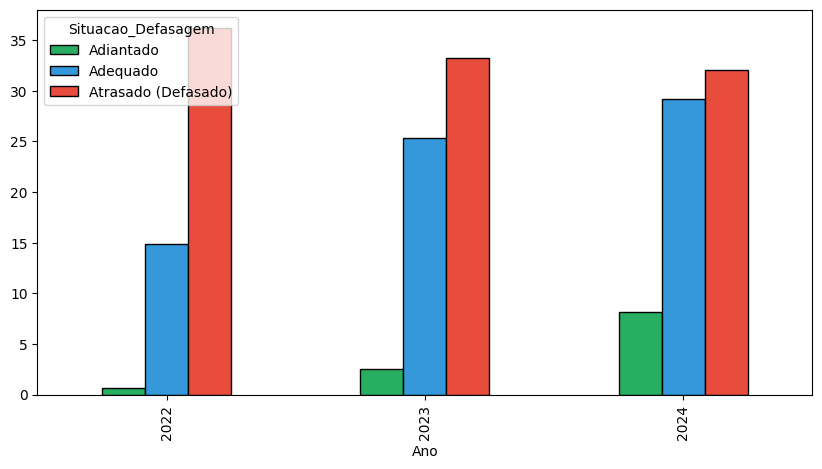

In [9]:
df_all['Defasagem'] = pd.to_numeric(df_all['Defasagem'], errors='coerce')
df_all['IAN'] = pd.to_numeric(df_all['IAN'], errors='coerce')

def classificar(v):
    if pd.isna(v): return 'Sem informação'
    if v < 0: return 'Atrasado (Defasado)'
    if v == 0: return 'Adequado'
    return 'Adiantado'

df_all['Situacao_Defasagem'] = df_all['Defasagem'].apply(classificar)


print("="*60)
print("PERFIL GERAL DE DEFASAGEM")
print("="*60)
print(df_all['Situacao_Defasagem'].value_counts())
print("\nProporção (%):")
print((df_all['Situacao_Defasagem'].value_counts(normalize=True)*100).round(1))

print("\n" + "="*60)
print("EVOLUÇÃO POR ANO (%)")
print("="*60)
evolucao = (
    pd.crosstab(df_all['Ano'], df_all['Situacao_Defasagem'], normalize='index')
    * 100
).round(1)
print(evolucao)


print("\nMédia de IAN por Ano:")
print(df_all.groupby('Ano')['IAN'].mean().round(2))


cols = [c for c in ['Adiantado', 'Adequado', 'Atrasado (Defasado)'] if c in evolucao.columns]
cores = {'Adiantado': '#27ae60', 'Adequado': '#3498db', 'Atrasado (Defasado)': '#e74c3c'}

ax = evolucao[cols].plot(
    kind='bar', figsize=(10, 5),
    color=[cores[c] for c in cols], edgecolor='black'
)


R: Conseguimos perceber uma evolução por ano da quantidade de Adiantados e Adequado e uma retração de Defasado.

# 2. Desempenho acadêmico (IDA)

O desempenho acadêmico médio (IDA) está melhorando, estagnado ou
caindo ao longo das fases e anos?

MÉDIA DE IDA POR FASE AO LONGO DOS ANOS
Fase   0.0   1.0   2.0   3.0   4.0   5.0   6.0   7.0  8.0  9.0  NAN  \
Ano                                                                   
2022  7.14  6.46  5.41  5.14  6.05  5.87  6.69  5.25  NaN  NaN  NaN   
2023  7.42  6.81  6.74  5.75  6.00  5.90  6.81  7.81  NaN  NaN  NaN   
2024  7.32  6.79  6.25  5.35  5.88  6.45  7.23  5.81  8.0  NaN  NaN   

Fase  Média Total  
Ano                
2022         6.09  
2023         6.66  
2024         6.35  


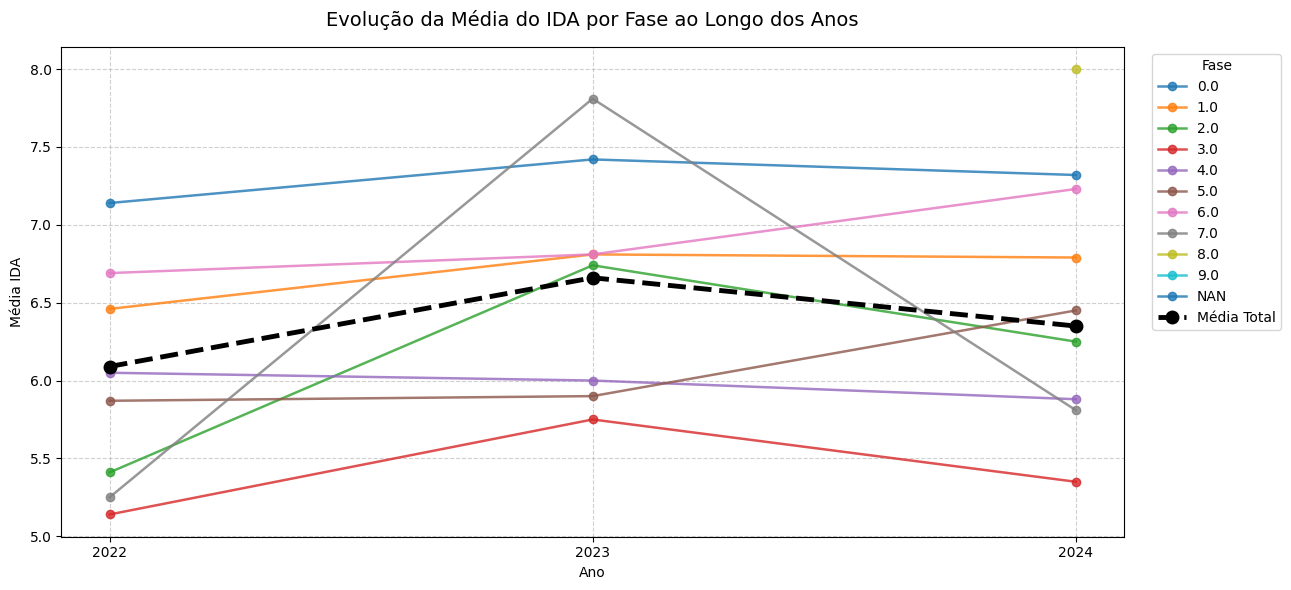

In [10]:
# 1. Preparação dos dados

df_all['IDA'] = pd.to_numeric(df_all['IDA'], errors='coerce')

# Garante que a coluna Fase esteja limpa
df_all['Fase'] = df_all['Fase'].astype(str).str.strip().str.upper()


# 2. Média de IDA por Fase e por Ano

print("="*70)
print("MÉDIA DE IDA POR FASE AO LONGO DOS ANOS")
print("="*70)

resumo_ida_fase = (
    df_all
    .groupby(['Ano', 'Fase'])['IDA']
    .mean()
    .round(2)
    .unstack()
)

# Ordena as fases de forma lógica
ordem_fases = ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5', 'FASE 6', 'FASE 7', 'FASE 8']
colunas_ordenadas = [c for c in ordem_fases if c in resumo_ida_fase.columns]
colunas_ordenadas += [c for c in resumo_ida_fase.columns if c not in colunas_ordenadas]

resumo_ida_fase = resumo_ida_fase[colunas_ordenadas]
resumo_ida_fase.index = resumo_ida_fase.index.astype(str)

# Adiciona a média total por ano
resumo_ida_fase['Média Total'] = df_all.groupby('Ano')['IDA'].mean().round(2).values

print(resumo_ida_fase)


# 3. Gráfico de evolução do IDA por Fase + Média Total

plt.figure(figsize=(13, 6))

# Plota cada fase
for fase in [c for c in resumo_ida_fase.columns if c != 'Média Total']:
    plt.plot(
        resumo_ida_fase.index,
        resumo_ida_fase[fase],
        marker='o',
        linewidth=1.8,
        markersize=6,
        label=fase,
        alpha=0.8
    )

# Plota a Média Total com destaque
plt.plot(
    resumo_ida_fase.index,
    resumo_ida_fase['Média Total'],
    marker='o',
    linewidth=3.5,
    markersize=9,
    label='Média Total',
    color='black',
    linestyle='--'
)

plt.title('Evolução da Média do IDA por Fase ao Longo dos Anos', fontsize=14, pad=15)
plt.xlabel('Ano')
plt.ylabel('Média IDA')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Fase', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



R: Tem uma tendência geral de subida

# 3 -  Engajamento nas atividades (IEG)
O grau de engajamento dos alunos (IEG) tem relação direta com seus
indicadores de desempenho (IDA) e do ponto de virada (IPV)?

Matriz de Correlação - IEG, IDA e IPV:
       IEG    IDA    IPV
IEG  1.000  0.539  0.558
IDA  0.539  1.000  0.557
IPV  0.558  0.557  1.000


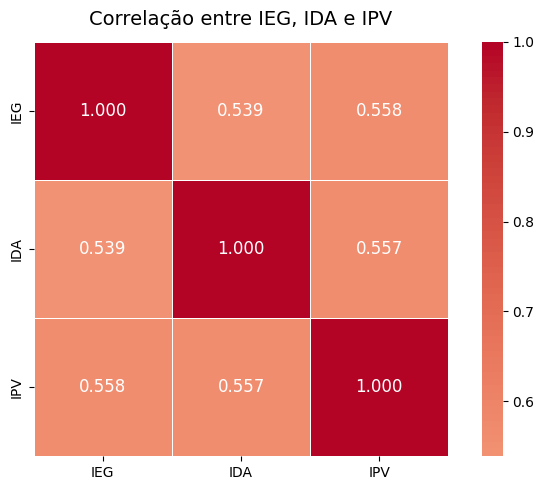

In [11]:
# Garante que as colunas estejam numéricas
cols = ['IEG', 'IDA', 'IPV']
df_corr = df_all[cols].apply(pd.to_numeric, errors='coerce')

# Calcula a matriz de correlação
corr_matrix = df_corr.corr().round(3)

print("Matriz de Correlação - IEG, IDA e IPV:")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.3f',
    linewidths=0.5,
    square=True,
    annot_kws={"size": 12}
)
plt.title('Correlação entre IEG, IDA e IPV', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

R: Existe uma correlação moderada positiva

alunos mais engajados tendem a ter melhor aprendizagem
alunos mais engajados também tendem a ter maior IPV
a relação existe, mas não é determinística (não é forte o suficiente para dizer que um explica o outro sozinho)

#4 -  Autoavaliação (IAA)
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu
desempenho real (IDA) e engajamento (IEG)?

=== Médias por Ano ===
       IAA   IDA   IEG
Ano                   
2022  8.27  6.09  7.89
2023  6.90  6.66  8.70
2024  8.54  6.35  7.37


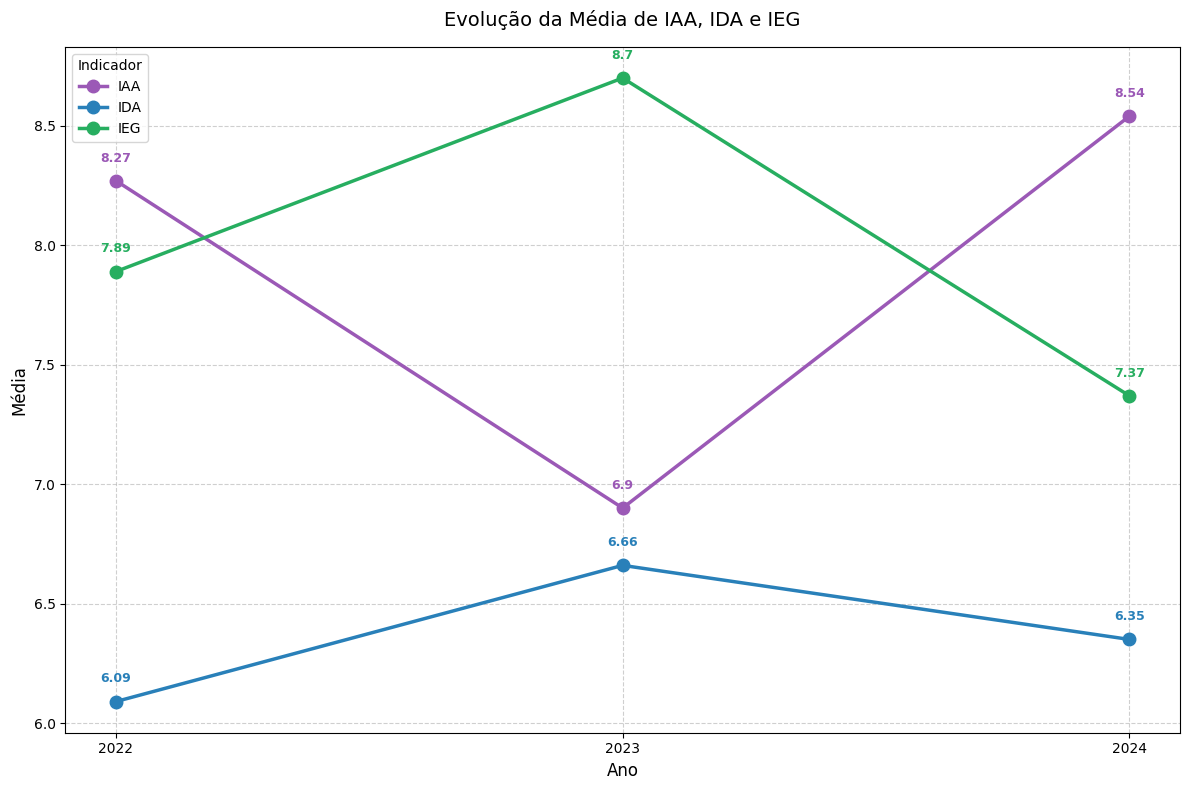

In [12]:
# Garante que as colunas estejam numéricas
df_all['IAA'] = pd.to_numeric(df_all['IAA'], errors='coerce')
df_all['IDA'] = pd.to_numeric(df_all['IDA'], errors='coerce')
df_all['IEG'] = pd.to_numeric(df_all['IEG'], errors='coerce')

# Calcula as médias por Ano
medias = (
    df_all
    .groupby('Ano')[['IAA', 'IDA', 'IEG']]
    .mean()
    .round(2)
)

# Garante que o índice seja string (para o gráfico)
medias.index = medias.index.astype(str)

print("=== Médias por Ano ===")
print(medias)

# ===== Gráfico de Linhas =====
plt.figure(figsize=(12, 8))

plt.plot(medias.index, medias['IAA'], marker='o', linewidth=2.5, markersize=9, label='IAA', color='#9b59b6')
plt.plot(medias.index, medias['IDA'], marker='o', linewidth=2.5, markersize=9, label='IDA', color='#2980b9')
plt.plot(medias.index, medias['IEG'], marker='o', linewidth=2.5, markersize=9, label='IEG', color='#27ae60')

# Colocar os valores nos pontos
for col, color in zip(['IAA', 'IDA', 'IEG'], ['#9b59b6', '#2980b9', '#27ae60']):
    for ano, valor in zip(medias.index, medias[col]):
        plt.text(ano, valor + 0.08, f'{valor}', ha='center', fontsize=9, fontweight='bold', color=color)

plt.title('Evolução da Média de IAA, IDA e IEG', fontsize=14, pad=15)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Média', fontsize=12)
plt.legend(title='Indicador')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

R: Não, a média de IAA conforme podemos observar acima sempre são acimas das médias de IDA e IEG

#5- Aspectos psicossociais (IPS)
Há padrões psicossociais (IPS) que antecedem quedas de desempenho
acadêmico ou de engajamento?

Registros com 2 anos consecutivos: 1253
Alunos únicos: 819

Correlação IPS (ano atual) × variação no ano seguinte:
  IPS → ΔIDA: 0.120
  IPS → ΔIEG: 0.195

Variação média no ano seguinte:
           delta_IDA  delta_IEG
IPS_grupo                      
IPS alto      -0.034     -0.132
IPS baixo     -0.397     -0.558


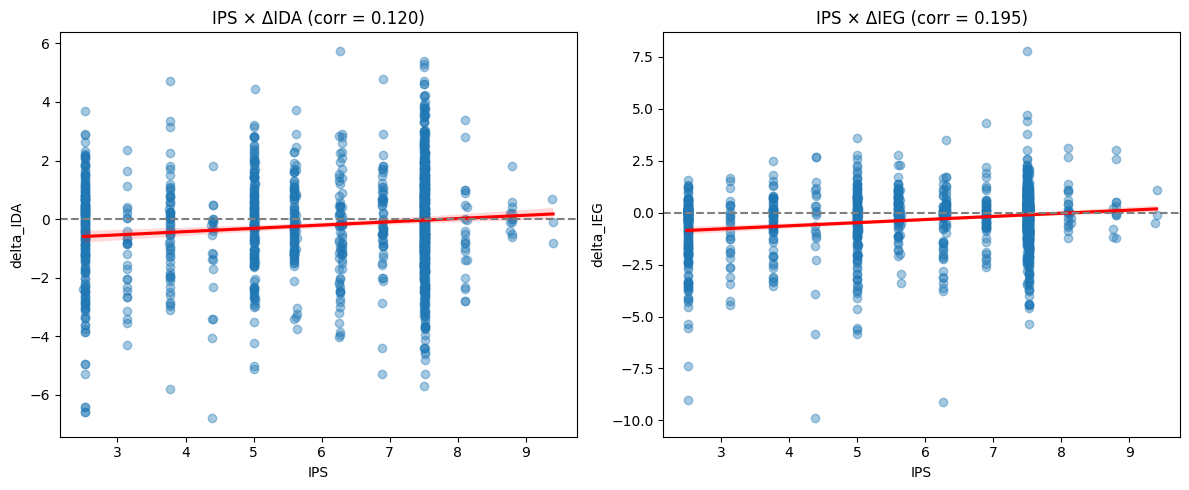

In [13]:
for col in ['IPS', 'IDA', 'IEG']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

df_all = df_all.sort_values(['RA', 'Ano'])


df_all['IDA_prox'] = df_all.groupby('RA')['IDA'].shift(-1)
df_all['IEG_prox'] = df_all.groupby('RA')['IEG'].shift(-1)

# Deltas
df_all['delta_IDA'] = df_all['IDA_prox'] - df_all['IDA']
df_all['delta_IEG'] = df_all['IEG_prox'] - df_all['IEG']

df_lag = df_all.dropna(subset=['IPS', 'delta_IDA', 'delta_IEG']).copy()

print(f"Registros com 2 anos consecutivos: {len(df_lag)}")
print(f"Alunos únicos: {df_lag['RA'].nunique()}")

# Correlações
corr_ida = df_lag['IPS'].corr(df_lag['delta_IDA'])
corr_ieg = df_lag['IPS'].corr(df_lag['delta_IEG'])

print("\nCorrelação IPS (ano atual) × variação no ano seguinte:")
print(f"  IPS → ΔIDA: {corr_ida:.3f}")
print(f"  IPS → ΔIEG: {corr_ieg:.3f}")

# IPS alto vs baixo
med = df_lag['IPS'].median()
df_lag['IPS_grupo'] = np.where(df_lag['IPS'] < med, 'IPS baixo', 'IPS alto')

resumo = df_lag.groupby('IPS_grupo')[['delta_IDA', 'delta_IEG']].mean().round(3)
print("\nVariação média no ano seguinte:")
print(resumo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=df_lag, x='IPS', y='delta_IDA', ax=axes[0],
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title(f'IPS × ΔIDA (corr = {corr_ida:.3f})')

sns.regplot(data=df_lag, x='IPS', y='delta_IEG', ax=axes[1],
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title(f'IPS × ΔIEG (corr = {corr_ieg:.3f})')

plt.tight_layout()
plt.show()

R: Demonstra uma relação positiva fraca

# 6- Aspectos psicopedagógicos
As avaliações psicopedagógicas (IPP) confirmam ou contradizem a
defasagem identificada pelo IAN?

Total de registros: 1992
Anos disponíveis: [np.int64(2023), np.int64(2024)]

Matriz de Correlação (todos os anos):
       IAN    IPP
IAN  1.000  0.123
IPP  0.123  1.000

Correlação IAN × IPP: 0.123

Correlação por Ano:
  2023: 0.095  (n = 938)
  2024: 0.154  (n = 1054)


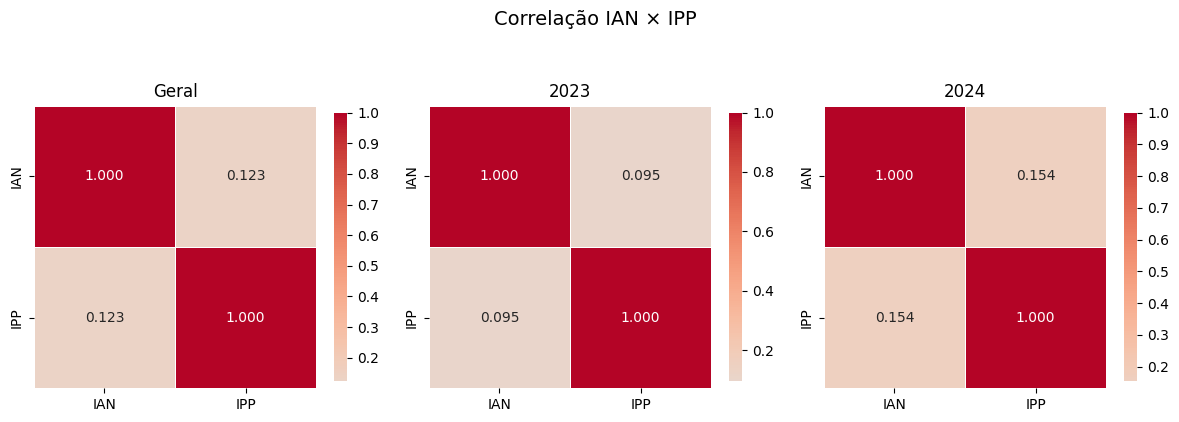

In [14]:
# Garante que as colunas estejam numéricas
df_all['IAN'] = pd.to_numeric(df_all['IAN'], errors='coerce')
df_all['IPP'] = pd.to_numeric(df_all['IPP'], errors='coerce')

# Usa todos os anos que tiverem IAN e IPP preenchidos
df_filtro = df_all[['Ano', 'IAN', 'IPP']].dropna()
anos = sorted(df_filtro['Ano'].unique())

print(f"Total de registros: {len(df_filtro)}")
print(f"Anos disponíveis: {anos}")


# 1. Correlação geral

corr_geral = df_filtro[['IAN', 'IPP']].corr().round(3)
print("\nMatriz de Correlação (todos os anos):")
print(corr_geral)
print(f"\nCorrelação IAN × IPP: {corr_geral.loc['IAN', 'IPP']:.3f}")

# 2. Correlação por ano

print("\nCorrelação por Ano:")
for ano in anos:
    df_ano = df_filtro[df_filtro['Ano'] == ano]
    corr = df_ano['IAN'].corr(df_ano['IPP'])
    print(f"  {ano}: {corr:.3f}  (n = {len(df_ano)})")


# 3. Heatmaps

n_anos = len(anos)
fig, axes = plt.subplots(1, n_anos + 1, figsize=(4 * (n_anos + 1), 4))

if n_anos == 0:
    print("Sem dados para plotar.")
else:
    # Heatmap geral
    sns.heatmap(
        corr_geral, annot=True, cmap='coolwarm', center=0,
        fmt='.3f', linewidths=0.5, square=True, ax=axes[0],
        cbar_kws={'shrink': 0.8}
    )
    axes[0].set_title('Geral', fontsize=12)

    # Heatmap por ano
    for i, ano in enumerate(anos):
        corr_ano = df_filtro[df_filtro['Ano'] == ano][['IAN', 'IPP']].corr()
        sns.heatmap(
            corr_ano, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', linewidths=0.5, square=True, ax=axes[i + 1],
            cbar_kws={'shrink': 0.8}
        )
        axes[i + 1].set_title(str(int(ano)), fontsize=12)

    plt.suptitle('Correlação IAN × IPP', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

R: Não apresenta correlação, sem grande impacto aparentemente

# 7- Ponto de virada (IPV)
Quais comportamentos - acadêmicos, emocionais ou de engajamento -
mais influenciam o IPV ao longo do tempo?  

CORRELAÇÃO TOTAL COM O IPV (todos os anos)
Indicador       Categoria  Correlação com IPV
      IPP Emocional/Psico               0.607
      IEG     Engajamento               0.558
      IDA       Acadêmico               0.557
      IAN       Acadêmico               0.149
      IAA Emocional/Psico               0.063
      IPS Emocional/Psico              -0.049


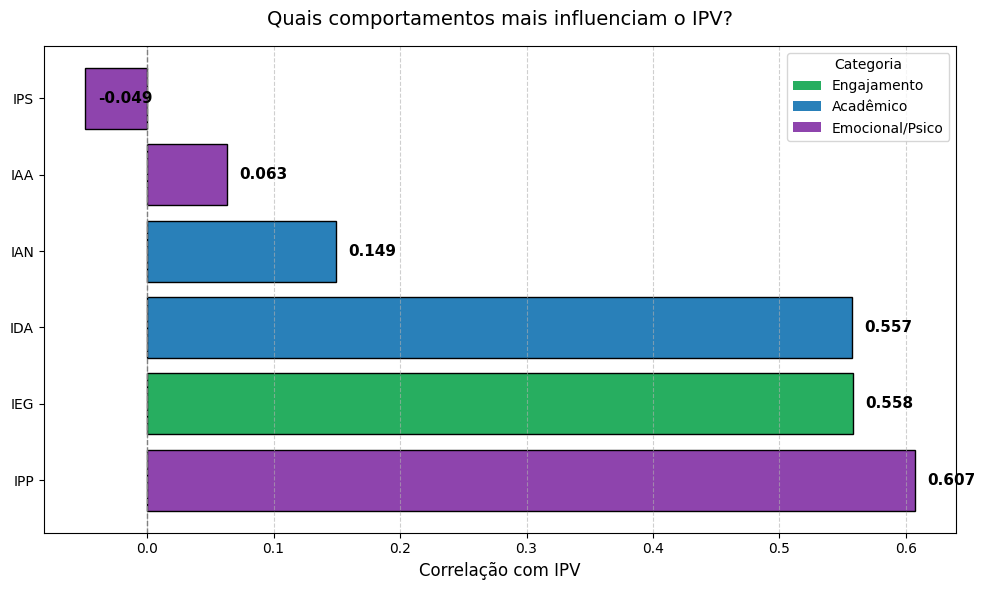

In [15]:
# 1. Definição dos indicadores por categoria

indicadores = {
    'Engajamento': ['IEG'],
    'Acadêmico': ['IDA', 'IAN'],
    'Emocional/Psico': ['IAA', 'IPS', 'IPP']
}


# 2. Garante que as colunas estejam numéricas

cols_para_analise = ['IPV'] + [ind for lista in indicadores.values() for ind in lista]
for col in cols_para_analise:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors='coerce')


# 3. Correlações totais com o IPV

resultados = []

for categoria, lista_inds in indicadores.items():
    for ind in lista_inds:
        if ind in df_all.columns and 'IPV' in df_all.columns:
            corr = df_all['IPV'].corr(df_all[ind])
            resultados.append({
                'Indicador': ind,
                'Categoria': categoria,
                'Correlação com IPV': round(corr, 3) if pd.notna(corr) else np.nan
            })

df_corr = pd.DataFrame(resultados).sort_values('Correlação com IPV', ascending=False)


# 4. Tabela resumo

print("="*60)
print("CORRELAÇÃO TOTAL COM O IPV (todos os anos)")
print("="*60)
print(df_corr.to_string(index=False))


# 5. Gráfico de barras

plt.figure(figsize=(10, 6))

cores = df_corr['Categoria'].map({
    'Engajamento': '#27ae60',
    'Acadêmico': '#2980b9',
    'Emocional/Psico': '#8e44ad'
})

bars = plt.barh(df_corr['Indicador'], df_corr['Correlação com IPV'], color=cores, edgecolor='black')

for bar, valor in zip(bars, df_corr['Correlação com IPV']):
    plt.text(valor + 0.01, bar.get_y() + bar.get_height()/2,
             f'{valor:.3f}', va='center', fontsize=11, fontweight='bold')

plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Quais comportamentos mais influenciam o IPV?', fontsize=14, pad=15)
plt.xlabel('Correlação com IPV', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Legenda manual das categorias
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='Engajamento'),
    Patch(facecolor='#2980b9', label='Acadêmico'),
    Patch(facecolor='#8e44ad', label='Emocional/Psico')
]
plt.legend(handles=legend_elements, title='Categoria')

plt.tight_layout()
plt.show()

R: IPP, IEG e IDA são os que mais impactam

# 8 - Multidimensionalidade dos indicadores
Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais
a nota global do aluno (INDE)?

Total de registros: 1985

1. CORRELAÇÃO COM O INDE
Indicador  Correlação com INDE
      IDA                0.767
      IEG                0.709
      IPP                0.540
      IPS                0.248

2. MÉDIA DO INDE POR QTD DE INDICADORES ALTOS
           Média INDE  Qtd Alunos
Qtd_Altos                        
0                6.04         187
1                6.64         445
2                7.22         500
3                7.97         546
4                8.42         307

3. COMBINAÇÕES ESPECÍFICAS
                   Combinação  Média INDE  Qtd Alunos
                  Nenhum alto        6.04         187
              IDA + IEG altos        8.18         675
        IDA + IEG + IPP altos        8.27         573
Todos altos (IDA+IEG+IPS+IPP)        8.42         307


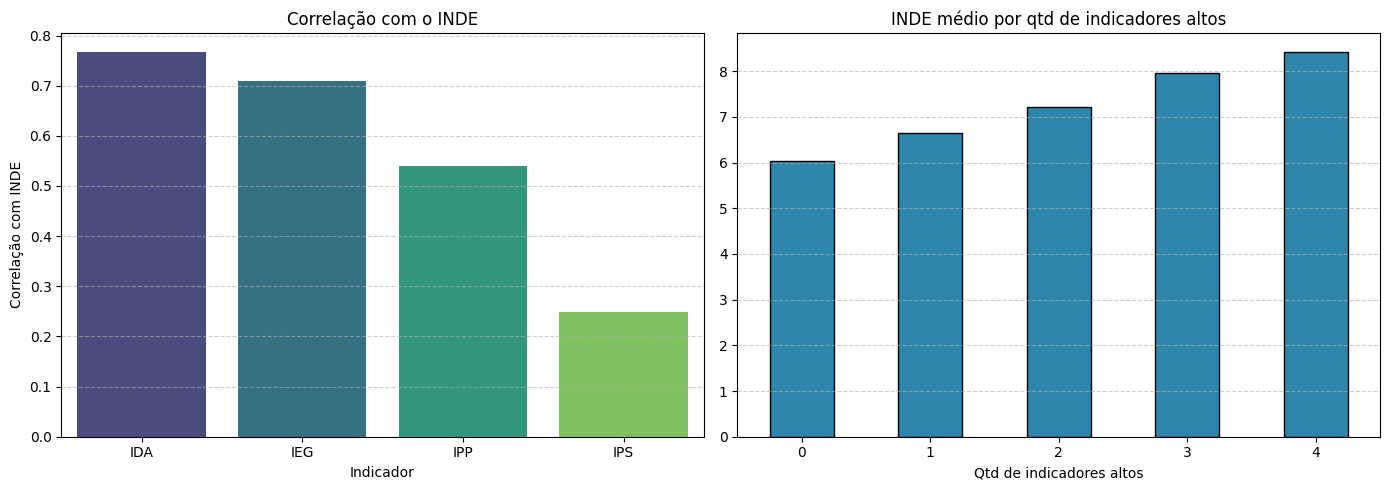

In [16]:
# 1. Preparação
indicadores = ['IDA', 'IEG', 'IPS', 'IPP']
cols = ['INDE'] + indicadores

for col in cols:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

df_mult = df_all[cols].dropna().copy()
print(f"Total de registros: {len(df_mult)}")


# 2. Correlação individual com INDE

print("\n1. CORRELAÇÃO COM O INDE")
corr_list = []
for ind in indicadores:
    corr = df_mult['INDE'].corr(df_mult[ind])
    corr_list.append({'Indicador': ind, 'Correlação com INDE': round(corr, 3)})

df_corr = pd.DataFrame(corr_list).sort_values('Correlação com INDE', ascending=False)
print(df_corr.to_string(index=False))


# 3. Qtd de indicadores altos × média do INDE

print("\n2. MÉDIA DO INDE POR QTD DE INDICADORES ALTOS")
df_temp = df_mult.copy()

for ind in indicadores:
    df_temp[f'{ind}_alto'] = (df_temp[ind] >= df_temp[ind].median()).astype(int)

df_temp['Qtd_Altos'] = df_temp[[f'{ind}_alto' for ind in indicadores]].sum(axis=1)

combinacoes = (
    df_temp.groupby('Qtd_Altos')['INDE']
    .agg(['mean', 'count'])
    .round(2)
)
combinacoes.columns = ['Média INDE', 'Qtd Alunos']
print(combinacoes)


# 4. Combinações específicas

print("\n3. COMBINAÇÕES ESPECÍFICAS")
df_temp['IDA_IEG'] = ((df_temp['IDA_alto']==1) & (df_temp['IEG_alto']==1)).astype(int)
df_temp['IDA_IEG_IPP'] = ((df_temp['IDA_alto']==1) & (df_temp['IEG_alto']==1) & (df_temp['IPP_alto']==1)).astype(int)
df_temp['TODOS'] = (df_temp['Qtd_Altos']==4).astype(int)

resumo = pd.DataFrame({
    'Combinação': [
        'Nenhum alto',
        'IDA + IEG altos',
        'IDA + IEG + IPP altos',
        'Todos altos (IDA+IEG+IPS+IPP)'
    ],
    'Média INDE': [
        df_temp.loc[df_temp['Qtd_Altos']==0, 'INDE'].mean(),
        df_temp.loc[df_temp['IDA_IEG']==1, 'INDE'].mean(),
        df_temp.loc[df_temp['IDA_IEG_IPP']==1, 'INDE'].mean(),
        df_temp.loc[df_temp['TODOS']==1, 'INDE'].mean()
    ],
    'Qtd Alunos': [
        (df_temp['Qtd_Altos']==0).sum(),
        int(df_temp['IDA_IEG'].sum()),
        int(df_temp['IDA_IEG_IPP'].sum()),
        int(df_temp['TODOS'].sum())
    ]
}).round(2)

print(resumo.to_string(index=False))


# 5. Gráficos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_corr, x='Indicador', y='Correlação com INDE',
            ax=axes[0], palette='viridis', hue='Indicador', legend=False)
axes[0].set_title('Correlação com o INDE')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

combinacoes['Média INDE'].plot(kind='bar', ax=axes[1], color='#2E86AB', edgecolor='black')
axes[1].set_title('INDE médio por qtd de indicadores altos')
axes[1].set_xlabel('Qtd de indicadores altos')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 9 - Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?

In [17]:
# 1. Preparação

inds = ['IDA', 'IEG', 'IPS', 'IPP', 'IPV', 'IAA', 'Defasagem']
for c in inds:
    if c in df_all.columns:
        df_all[c] = pd.to_numeric(df_all[c], errors='coerce')

df_all = df_all.sort_values(['RA', 'Ano'])

# Ano seguinte
df_all['IDA_prox'] = df_all.groupby('RA')['IDA'].shift(-1)
df_all['IEG_prox'] = df_all.groupby('RA')['IEG'].shift(-1)
df_all['Defasagem_prox'] = df_all.groupby('RA')['Defasagem'].shift(-1)

df_all['delta_IDA'] = df_all['IDA_prox'] - df_all['IDA']
df_all['delta_IEG'] = df_all['IEG_prox'] - df_all['IEG']
df_all['delta_Defasagem'] = df_all['Defasagem_prox'] - df_all['Defasagem']

df_lag = df_all.dropna(subset=['delta_IDA', 'delta_IEG', 'delta_Defasagem']).copy()
print(f"Registros com 2 anos consecutivos: {len(df_lag)}")


# 2. Correlação: indicadores atuais × variação futura

print("\nCorrelação com Δ Defasagem (ano seguinte):")
for c in ['IDA', 'IEG', 'IPS', 'IPP', 'IPV', 'IAA']:
    if c in df_lag.columns:
        print(f"  {c} → ΔDefasagem: {df_lag[c].corr(df_lag['delta_Defasagem']):.3f}")

print("\nCorrelação com queda de desempenho/engajamento:")
for c in ['IDA', 'IEG', 'IPS', 'IPP', 'IPV', 'IAA']:
    if c in df_lag.columns:
        print(f"  {c} → ΔIDA: {df_lag[c].corr(df_lag['delta_IDA']):.3f} | "
              f"ΔIEG: {df_lag[c].corr(df_lag['delta_IEG']):.3f}")


# 3. Padrão: quantidade de indicadores baixos

base = ['IDA', 'IEG', 'IPS', 'IPP', 'IPV']  # sem IAN
for c in base:
    df_lag[f'{c}_baixo'] = (df_lag[c] < df_lag[c].median()).astype(int)

df_lag['Qtd_Baixos'] = df_lag[[f'{c}_baixo' for c in base]].sum(axis=1)

print("\nVariação média no ano seguinte por qtd de indicadores baixos:")
print(
    df_lag.groupby('Qtd_Baixos')[['delta_IDA', 'delta_IEG', 'delta_Defasagem']]
    .mean()
    .round(3)
)

Registros com 2 anos consecutivos: 1256

Correlação com Δ Defasagem (ano seguinte):
  IDA → ΔDefasagem: 0.150
  IEG → ΔDefasagem: 0.113
  IPS → ΔDefasagem: -0.130
  IPP → ΔDefasagem: 0.306
  IPV → ΔDefasagem: 0.241
  IAA → ΔDefasagem: -0.018

Correlação com queda de desempenho/engajamento:
  IDA → ΔIDA: -0.435 | ΔIEG: -0.028
  IEG → ΔIDA: -0.159 | ΔIEG: -0.338
  IPS → ΔIDA: 0.120 | ΔIEG: 0.195
  IPP → ΔIDA: -0.080 | ΔIEG: 0.088
  IPV → ΔIDA: -0.188 | ΔIEG: -0.083
  IAA → ΔIDA: 0.051 | ΔIEG: 0.110

Variação média no ano seguinte por qtd de indicadores baixos:
            delta_IDA  delta_IEG  delta_Defasagem
Qtd_Baixos                                       
0              -0.592     -0.260            0.318
1              -0.500     -0.283            0.390
2              -0.272     -0.421            0.245
3               0.138     -0.150            0.049
4               0.053     -0.439            0.091
5              -0.041     -0.853           -0.132


R: Sinais que podemos perceber ->

IEG baixo → risco de piora de engajamento
IPS baixo → pior trajetória de engajamento

#9.1 Modelo Preditivo - RANDOM FOREST

1. BALANCEAMENTO DAS CLASSES
RISCO
1    1687
0    1343
Name: count, dtype: int64

Proporção (%):
RISCO
1    55.7
0    44.3
Name: proportion, dtype: float64

Total de alunos com Defasagem preenchida: 3030


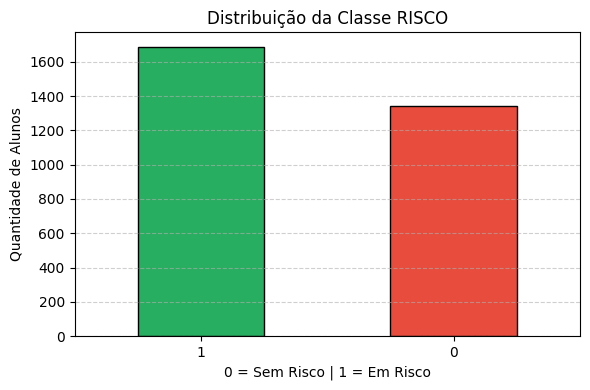

In [18]:
warnings.filterwarnings('ignore')

# 1. Target: Risco de Defasagem

df_all['Defasagem'] = pd.to_numeric(df_all['Defasagem'], errors='coerce')
df_all['RISCO'] = (df_all['Defasagem'] < 0).astype(int)

# Remove linhas sem Defasagem/RISCO válido
df_risco = df_all.dropna(subset=['Defasagem']).copy()

print("="*60)
print("1. BALANCEAMENTO DAS CLASSES")
print("="*60)
print(df_risco['RISCO'].value_counts())
print("\nProporção (%):")
print((df_risco['RISCO'].value_counts(normalize=True) * 100).round(1))
print(f"\nTotal de alunos com Defasagem preenchida: {len(df_risco)}")

plt.figure(figsize=(6, 4))
df_risco['RISCO'].value_counts().plot(
    kind='bar', color=['#27ae60', '#e74c3c'], edgecolor='black'
)
plt.title('Distribuição da Classe RISCO')
plt.xlabel('0 = Sem Risco | 1 = Em Risco')
plt.ylabel('Quantidade de Alunos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
# 1. Target

df_all['Defasagem'] = pd.to_numeric(df_all['Defasagem'], errors='coerce')
df_all['RISCO'] = (df_all['Defasagem'] < 0).astype(int)


# 2. Fase_Num
# Se Fase já estiver numérica, isso resolve; se ainda tiver texto, também
df_all['Fase_Num'] = pd.to_numeric(df_all['Fase'], errors='coerce')


# 3. Features
features_candidatas = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Fase_Num']


if 'Ano_Ingresso' in df_all.columns and 'Ano' in df_all.columns:
    df_all['Anos_No_Programa'] = (
        pd.to_numeric(df_all['Ano'], errors='coerce')
        - pd.to_numeric(df_all['Ano_Ingresso'], errors='coerce')
    ).clip(lower=0)
    if df_all['Anos_No_Programa'].notna().sum() > 100:
        features_candidatas.append('Anos_No_Programa')

for col in features_candidatas:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

df_modelo = df_all[features_candidatas + ['RISCO']].dropna().copy()

print(f"Total de alunos após limpeza: {len(df_modelo)}")
print(f"Taxa de risco: {df_modelo['RISCO'].mean():.1%}")
print(f"Features utilizadas: {features_candidatas}")
print("\nBalanceamento:")
print(df_modelo['RISCO'].value_counts(normalize=True).round(3) * 100)

Total de alunos após limpeza: 1985
Taxa de risco: 54.3%
Features utilizadas: ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Fase_Num', 'Anos_No_Programa']

Balanceamento:
RISCO
1    54.3
0    45.7
Name: proportion, dtype: float64


In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report
from xgboost import XGBClassifier

# Split

X = df_modelo[features_candidatas]
y = df_modelo['RISCO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale_pos = (y_train == 0).sum() / max(1, (y_train == 1).sum())


# Modelos + grids

modelos = {
    'Logistic Regression': {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=2000, random_state=42))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__class_weight': ['balanced', None]
        }
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [200, 300],
            'max_depth': [5, 6, 8],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2, 5],
            'class_weight': ['balanced', None]
        }
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        ),
        'params': {
            'n_estimators': [200, 300],
            'max_depth': [3, 4, 6],
            'learning_rate': [0.05, 0.1],
            'scale_pos_weight': [1, scale_pos]
        }
    },
    'MLP (Rede Neural)': {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(max_iter=500, random_state=42))
        ]),
        'params': {
            'clf__hidden_layer_sizes': [(32,), (64, 32)],
            'clf__alpha': [0.0001, 0.001],
            'clf__learning_rate_init': [0.001, 0.01]
        }
    }
}


# Treino e comparação

resultados = []

print("Treinando modelos...\n")
for nome, cfg in modelos.items():
    print(f"→ {nome}")
    grid = GridSearchCV(
        cfg['estimator'],
        cfg['params'],
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)

    y_proba = grid.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.40).astype(int)

    resultados.append({
        'Modelo': nome,
        'AUC-ROC (CV)': round(grid.best_score_, 4),
        'AUC-ROC (Teste)': round(roc_auc_score(y_test, y_proba), 4),
        'AUC-PR': round(average_precision_score(y_test, y_proba), 4),
        'F1 (thr=0.40)': round(f1_score(y_test, y_pred), 4),
        'Melhores params': grid.best_params_,
        'modelo': grid.best_estimator_
    })
    print(f"  AUC-ROC CV: {grid.best_score_:.4f} | Teste: {roc_auc_score(y_test, y_proba):.4f}")


# Ranking

df_result = pd.DataFrame(resultados).sort_values('AUC-ROC (Teste)', ascending=False)

print("\n" + "="*70)
print("COMPARAÇÃO DOS MODELOS")
print("="*70)
display(df_result[['Modelo', 'AUC-ROC (CV)', 'AUC-ROC (Teste)', 'AUC-PR', 'F1 (thr=0.40)']])

melhor = df_result.iloc[0]
print(f"\n>>> Melhor modelo: {melhor['Modelo']}")
print(f">>> Params: {melhor['Melhores params']}")

Treinando modelos...

→ Logistic Regression
  AUC-ROC CV: 0.6146 | Teste: 0.6254
→ Random Forest
  AUC-ROC CV: 0.7158 | Teste: 0.7476
→ XGBoost
  AUC-ROC CV: 0.7268 | Teste: 0.7385
→ MLP (Rede Neural)
  AUC-ROC CV: 0.6940 | Teste: 0.7330

COMPARAÇÃO DOS MODELOS


,Modelo,AUC-ROC (CV),AUC-ROC (Teste),AUC-PR,F1 (thr=0.40)
1,Random Forest,0.7158,0.7476,0.7657,0.7487
2,XGBoost,0.7268,0.7385,0.7569,0.7280
3,MLP (Rede Neural),0.6940,0.7330,0.7793,0.7221
0,Logistic Regression,0.6146,0.6254,0.6489,0.6931



>>> Melhor modelo: Random Forest
>>> Params: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


Features do modelo: ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Fase_Num', 'Anos_No_Programa']
MODELO: Random Forest | Threshold = 0.4
              precision    recall  f1-score   support

   Sem Risco       0.78      0.38      0.51       272
    Em Risco       0.64      0.91      0.75       324

    accuracy                           0.67       596
   macro avg       0.71      0.64      0.63       596
weighted avg       0.70      0.67      0.64       596

AUC-ROC: 0.7476

TN=103 | FP=169 | FN=29 | TP=295


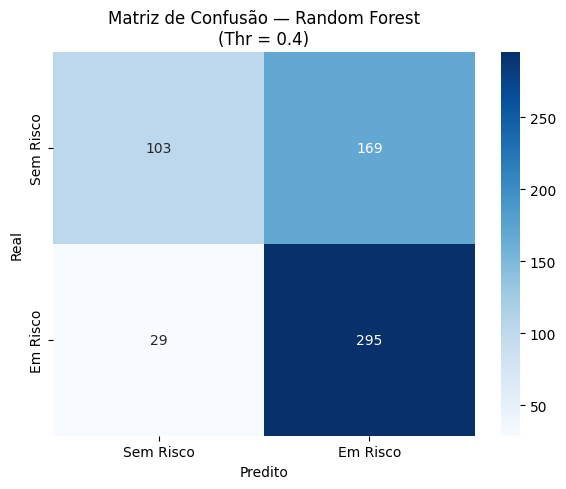

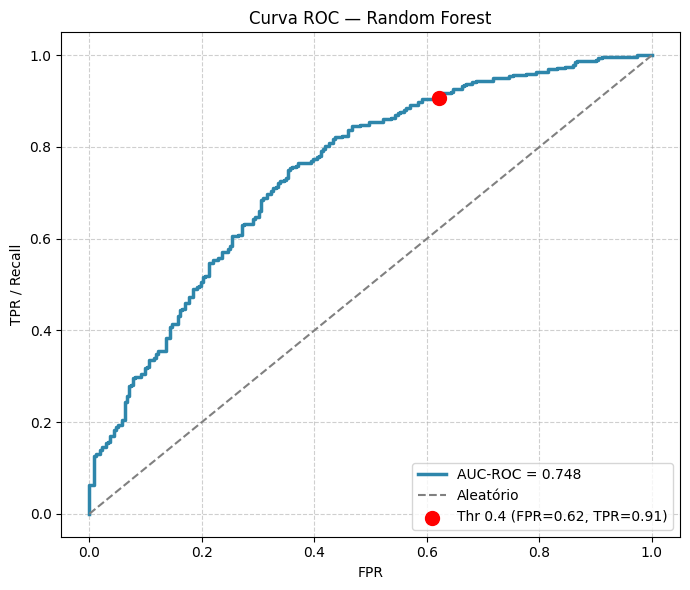


Importância das features:
Fase_Num            0.1643
IPV                 0.1529
IEG                 0.1451
IDA                 0.1312
IPP                 0.1179
Anos_No_Programa    0.0987
IPS                 0.0956
IAA                 0.0941
dtype: float64


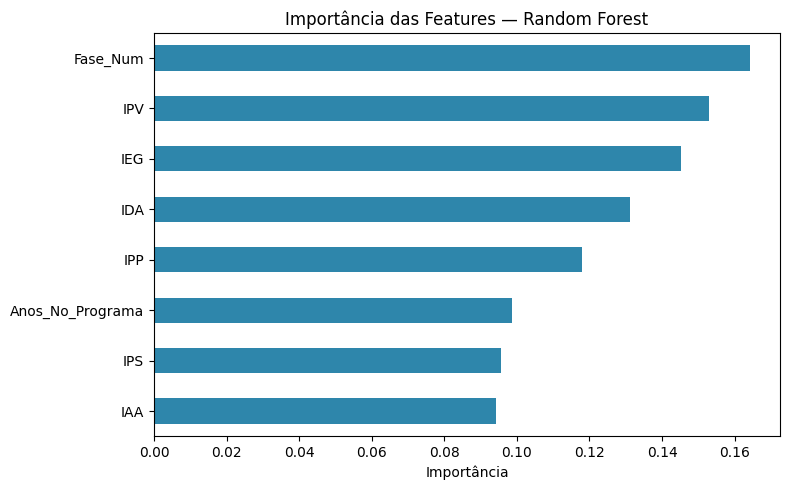

In [21]:
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

# 1. Modelo do benchmark

melhor_modelo = df_result.iloc[0]['modelo']
nome_modelo = df_result.iloc[0]['Modelo']

# Features que o modelo espera
features_modelo = list(melhor_modelo.feature_names_in_)
print("Features do modelo:", features_modelo)

# Recria X_test com as MESMAS features do treino
# (use o df_modelo SEM delta, ou monte a partir do df_all)
features_sem = [c for c in features_modelo if c in df_all.columns]

df_eval = df_all[features_sem + ['RISCO']].dropna().copy()
X_eval = df_eval[features_sem]
y_eval = df_eval['RISCO']

from sklearn.model_selection import train_test_split
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eval, y_eval, test_size=0.30, random_state=42, stratify=y_eval
)

# Garante a mesma ordem das colunas
X_test_e = X_test_e[features_modelo]

y_proba = melhor_modelo.predict_proba(X_test_e)[:, 1]
y_test = y_test_e  # para o restante do código

# 2. Threshold + relatório

threshold = 0.40
y_pred = (y_proba >= threshold).astype(int)

print("="*60)
print(f"MODELO: {nome_modelo} | Threshold = {threshold}")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Sem Risco', 'Em Risco']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")


# 3. Matriz de Confusão

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn} | FP={fp} | FN={fn} | TP={tp}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Risco', 'Em Risco'],
            yticklabels=['Sem Risco', 'Em Risco'])
plt.title(f'Matriz de Confusão — {nome_modelo}\n(Thr = {threshold})')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

# 4. Curva ROC

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2E86AB', lw=2.5, label=f'AUC-ROC = {auc:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório')
idx = np.argmin(np.abs(thresholds_roc - threshold))
plt.scatter(fpr[idx], tpr[idx], color='red', s=100, zorder=5,
            label=f'Thr {threshold} (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})')
plt.xlabel('FPR')
plt.ylabel('TPR / Recall')
plt.title(f'Curva ROC — {nome_modelo}')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 5. Importância das Features

estimador = melhor_modelo
if hasattr(melhor_modelo, 'named_steps') and 'clf' in melhor_modelo.named_steps:
    estimador = melhor_modelo.named_steps['clf']

if hasattr(estimador, 'feature_importances_'):
    importances = pd.Series(
        estimador.feature_importances_, index=features_modelo
    ).sort_values()
    print("\nImportância das features:")
    print(importances.sort_values(ascending=False).round(4))

    plt.figure(figsize=(8, 5))
    importances.plot(kind='barh', color='#2E86AB')
    plt.title(f'Importância das Features — {nome_modelo}')
    plt.xlabel('Importância')
    plt.tight_layout()
    plt.show()

# Random Forest com Deltas para capturar defasagem de alunos com pelo menos 2 anos dentro do programa

Total de alunos após limpeza: 678
Taxa de risco: 45.0%
Features (13): ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Fase_Num', 'delta_IDA', 'delta_IEG', 'delta_IAA', 'delta_IPS', 'delta_IPP', 'delta_IPV']
Treino: 474 | Teste: 204
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Melhores parâmetros: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Melhor AUC-ROC (CV): 0.8493

RESULTADOS — Random Forest + Deltas (Thr = 0.4)
              precision    recall  f1-score   support

   Sem Risco       0.84      0.65      0.73       112
    Em Risco       0.67      0.85      0.75        92

    accuracy                           0.74       204
   macro avg       0.75      0.75      0.74       204
weighted avg       0.76      0.74      0.74       204

AUC-ROC: 0.8286
AUC-PR:  0.7795

VARIAÇÃO DE THRESHOLD
   Thr |  Precision |   Recall |       F1
----------------------------------------
  0.40 |      0.667 |    0.848 | 

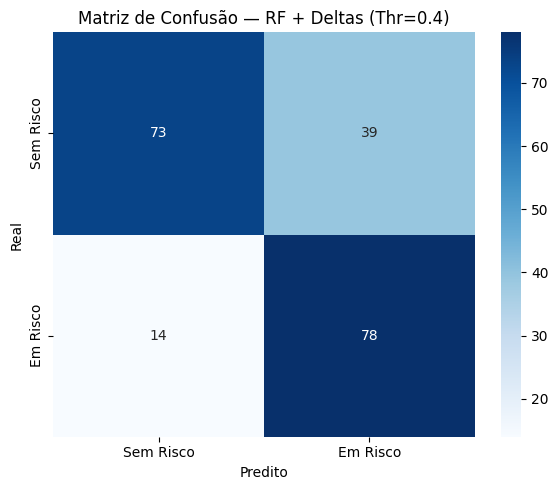

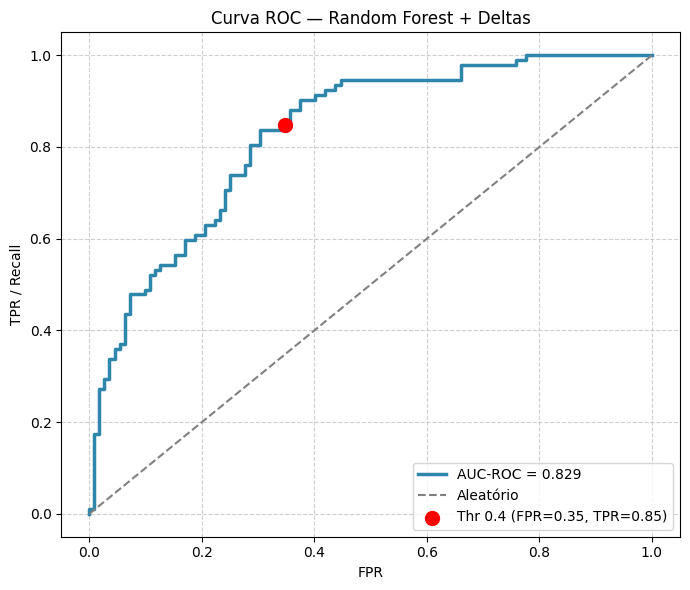

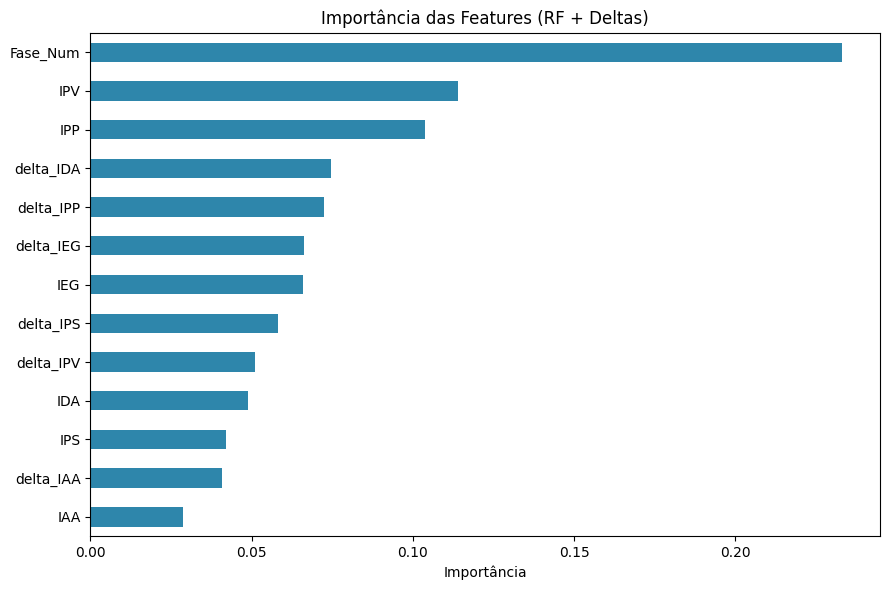

Fase_Num     0.2332
IPV          0.1139
IPP          0.1038
delta_IDA    0.0745
delta_IPP    0.0726
delta_IEG    0.0662
IEG          0.0659
delta_IPS    0.0581
delta_IPV    0.0511
IDA          0.0490
IPS          0.0422
delta_IAA    0.0408
IAA          0.0288
dtype: float64


In [22]:
#A ideia é ter a opção no streamlit para a pessoa selecionar se é nova ou não no programa, caso tenha um histórico de 2 anos pelo menos a previsão fica mais assertiva

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_score, recall_score, f1_score, roc_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')


# 1. Target

df_all['Defasagem'] = pd.to_numeric(df_all['Defasagem'], errors='coerce')
df_all['RISCO'] = (df_all['Defasagem'] < 0).astype(int)

# 2. Fase_Num

df_all['Fase_Num'] = pd.to_numeric(df_all['Fase'], errors='coerce')

# 3. Deltas

df_all = df_all.sort_values(['RA', 'Ano'])
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']

for col in indicadores:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
    df_all[f'delta_{col}'] = df_all.groupby('RA')[col].diff()

# 4. Features finais

features = [
    'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Fase_Num',
    'delta_IDA', 'delta_IEG', 'delta_IAA', 'delta_IPS', 'delta_IPP', 'delta_IPV'
]

df_modelo = df_all[features + ['RISCO']].dropna().copy()

print(f"Total de alunos após limpeza: {len(df_modelo)}")
print(f"Taxa de risco: {df_modelo['RISCO'].mean():.1%}")
print(f"Features ({len(features)}): {features}")

X = df_modelo[features]
y = df_modelo['RISCO']

# 5. Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

# 6. GridSearch Random Forest

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 6, 8],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': ['balanced', None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("\nMelhores parâmetros:", grid.best_params_)
print(f"Melhor AUC-ROC (CV): {grid.best_score_:.4f}")

modelo = grid.best_estimator_
y_proba = modelo.predict_proba(X_test)[:, 1]

# 7. Avaliação com threshold 0.40 (escolhido para recall)

threshold = 0.40
y_pred = (y_proba >= threshold).astype(int)

print("\n" + "="*60)
print(f"RESULTADOS — Random Forest + Deltas (Thr = {threshold})")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Sem Risco', 'Em Risco']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"AUC-PR:  {average_precision_score(y_test, y_proba):.4f}")

# 8. Variação de threshold

print("\n" + "="*60)
print("VARIAÇÃO DE THRESHOLD")
print("="*60)
print(f"{'Thr':>6} | {'Precision':>10} | {'Recall':>8} | {'F1':>8}")
print("-"*40)

for thr in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    y_t = (y_proba >= thr).astype(int)
    print(f"{thr:>6.2f} | {precision_score(y_test, y_t, zero_division=0):>10.3f} | "
          f"{recall_score(y_test, y_t):>8.3f} | {f1_score(y_test, y_t):>8.3f}")

# 9. Matriz de Confusão

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn} | FP={fp} | FN={fn} | TP={tp}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Risco', 'Em Risco'],
            yticklabels=['Sem Risco', 'Em Risco'])
plt.title(f'Matriz de Confusão — RF + Deltas (Thr={threshold})')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

# 10. Curva ROC

fpr, tpr, thr_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2E86AB', lw=2.5, label=f'AUC-ROC = {auc:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório')
idx = np.argmin(np.abs(thr_roc - threshold))
plt.scatter(fpr[idx], tpr[idx], color='red', s=100, zorder=5,
            label=f'Thr {threshold} (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})')
plt.xlabel('FPR')
plt.ylabel('TPR / Recall')
plt.title('Curva ROC — Random Forest + Deltas')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# Importância das features

importances = pd.Series(
    modelo.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='#2E86AB')
plt.title('Importância das Features (RF + Deltas)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).round(4))

In [23]:
import joblib


# 1. Modelo SEM delta

modelo_sem_delta = df_result.iloc[0]['modelo']
features_sem = list(modelo_sem_delta.feature_names_in_)

artefatos_sem = {
    'modelo': modelo_sem_delta,
    'features': features_sem,
    'threshold': 0.40,
    'tipo': 'sem_delta',
    'best_params': df_result.iloc[0]['Melhores params']
}
joblib.dump(artefatos_sem, 'modelo_sem_delta.pkl')
print("Salvo: modelo_sem_delta.pkl")
print("Features SEM delta:", features_sem)


# 2. Modelo COM delta (vem do último treino RF + deltas)
artefatos_com = {
    'modelo': modelo,
    'features': features,
    'threshold': 0.40,
    'tipo': 'com_delta',
    'best_params': grid.best_params_
}
joblib.dump(artefatos_com, 'modelo_com_delta.pkl')
print("\nSalvo: modelo_com_delta.pkl")
print("Features COM delta:", features)

# 3. Conferência

print("\n" + "="*50)
print("ARQUIVOS GERADOS")
print("="*50)
print("modelo_sem_delta.pkl  → aluno novo (sem histórico)")
print("modelo_com_delta.pkl  → aluno com 2+ anos (com deltas)")

Salvo: modelo_sem_delta.pkl
Features SEM delta: ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Fase_Num', 'Anos_No_Programa']

Salvo: modelo_com_delta.pkl
Features COM delta: ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Fase_Num', 'delta_IDA', 'delta_IEG', 'delta_IAA', 'delta_IPS', 'delta_IPP', 'delta_IPV']

ARQUIVOS GERADOS
modelo_sem_delta.pkl  → aluno novo (sem histórico)
modelo_com_delta.pkl  → aluno com 2+ anos (com deltas)


# 10 - Efetividade do programa
Os indicadores mostram melhora consistente ao longo do ciclo nas
diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto
real do programa?

Registros válidos por Ano:
Ano
2022     860
2023     931
2024    1054
Name: Pedra_Final, dtype: int64

Distribuição percentual das Pedras por Ano:
Pedra_Final  Quartzo  Ágata  Ametista  Topázio
Ano                                           
2022            15.3   29.1      40.5     15.1
2023             7.7   26.4      40.9     24.9
2024            10.6   21.3      37.1     30.9


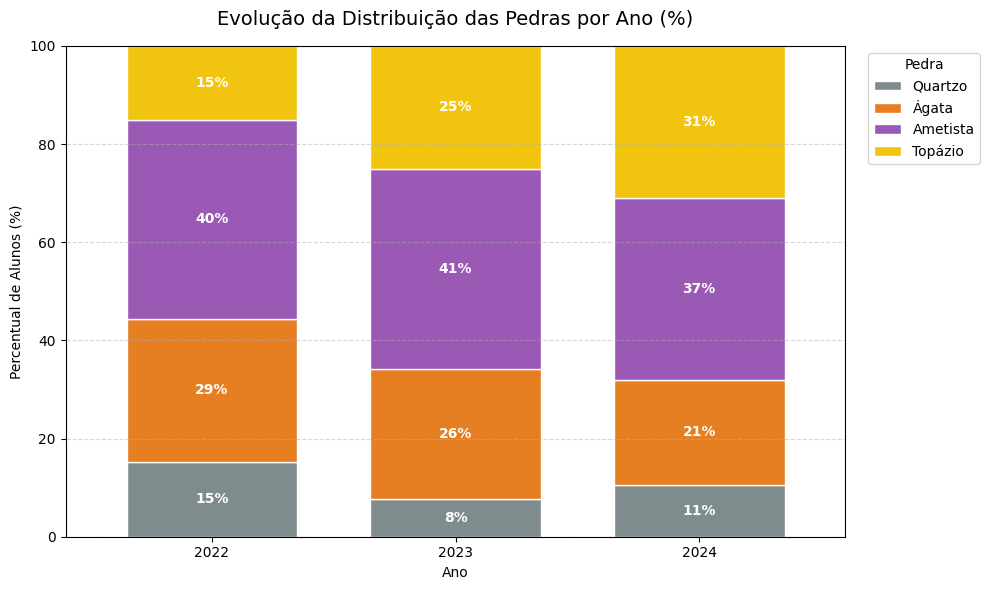

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 1. Preparar a coluna Pedra

df_all['Pedra_Final'] = (
    df_all['Pedra']
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'Agata': 'Ágata',
        'Ágata': 'Ágata',
        'Topazio': 'Topázio',
        'Topázio': 'Topázio',
        'Ametista': 'Ametista',
        'Quartzo': 'Quartzo',
        'Nan': np.nan,
        'None': np.nan
    })
)

pedras_validas = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df_pedra = df_all[df_all['Pedra_Final'].isin(pedras_validas)].copy()

print("Registros válidos por Ano:")
print(df_pedra.groupby('Ano')['Pedra_Final'].count())


# 2. Tabela percentual

tabela_pct = (
    pd.crosstab(df_pedra['Ano'], df_pedra['Pedra_Final'], normalize='index')
    .reindex(columns=pedras_validas)
    * 100
).round(1)

print("\nDistribuição percentual das Pedras por Ano:")
print(tabela_pct)


# 3. Gráfico de barras empilhadas

cores = {
    'Quartzo': '#7f8c8d',
    'Ágata': '#e67e22',
    'Ametista': '#9b59b6',
    'Topázio': '#f1c40f'
}

fig, ax = plt.subplots(figsize=(10, 6))

tabela_pct.plot(
    kind='bar',
    stacked=True,
    color=[cores[p] for p in pedras_validas],
    ax=ax,
    edgecolor='white',
    width=0.7
)

for i, ano in enumerate(tabela_pct.index):
    acumulado = 0
    for pedra in pedras_validas:
        valor = tabela_pct.loc[ano, pedra]
        if pd.notna(valor) and valor > 4:
            ax.text(i, acumulado + valor/2, f'{valor:.0f}%',
                    ha='center', va='center', fontsize=10,
                    fontweight='bold', color='white')
        acumulado += valor if pd.notna(valor) else 0

ax.set_title('Evolução da Distribuição das Pedras por Ano (%)', fontsize=14, pad=15)
ax.set_xlabel('Ano')
ax.set_ylabel('Percentual de Alunos (%)')
ax.set_xticklabels([int(a) for a in tabela_pct.index], rotation=0)
ax.legend(title='Pedra', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


R: Fica evidente nas evoluções das pedras, aparentemente tem uma migração de pessoas de Ametista e Ágata para Topázio, Quartzo apresenta uma queda se olhar de 2022 para 2024.

In [25]:
import pandas as pd
import numpy as np
from IPython.display import display


mapa_nomes = {
    'INDE': 'Índice do Desenvolvimento Educacional (INDE)',
    'IDA': 'Indicador de Aprendizagem (IDA)',
    'IEG': 'Indicador de Engajamento (IEG)',
    'IAN': 'Indicador de Adequação ao Nível (IAN)',
    'IPS': 'Indicador Psicossocial (IPS)',
    'IPP': 'Indicador Psicopedagógico (IPP)',
    'IPV': 'Indicador de Ponto de Virada (IPV)',
    'IAA': 'Indicador de Autoavaliação (IAA)',
    'Defasagem': 'Nível de Defasagem (Defasagem)'
}

indicadores = list(mapa_nomes.keys())

for col in indicadores:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors='coerce')


if 'INDE' not in df_all.columns or df_all['INDE'].isna().all():
    df_all['INDE'] = np.nan
    for ano, col in [(2023, 'INDE 2023'), (2024, 'INDE 2024')]:
        if col in df_all.columns:
            df_all.loc[df_all['Ano'] == ano, 'INDE'] = pd.to_numeric(
                df_all.loc[df_all['Ano'] == ano, col], errors='coerce')

cols = [c for c in indicadores if c in df_all.columns]


tabela = (
    df_all
    .groupby('Ano')[cols]
    .mean()
    .round(2)
    .sort_index()
    .T
)

tabela.index = [mapa_nomes.get(i, i) for i in tabela.index]


anos = list(tabela.columns)

for i in range(len(anos) - 1):
    a1, a2 = anos[i], anos[i + 1]
    tabela[f'{a1}→{a2}'] = (tabela[a2] - tabela[a1]).round(2)

if len(anos) >= 2:
    tabela[f'Total {anos[0]}→{anos[-1]}'] = (tabela[anos[-1]] - tabela[anos[0]]).round(2)

cols_var = [c for c in tabela.columns if '→' in str(c)]

tabela_fmt = tabela.copy()
for col in cols_var:
    tabela_fmt[col] = tabela[col].apply(
        lambda v: '-' if pd.isna(v) else (f'+{v:.2f}' if v > 0 else f'{v:.2f}')
    )

def colorir(row):
    cores = [''] * len(row)
    is_defasagem = 'Defasagem' in str(row.name)

    for col in cols_var:
        if col not in row.index:
            continue
        val_str = row[col]
        if val_str == '-':
            continue
        try:
            val = float(val_str)
        except:
            continue

        idx = row.index.get_loc(col)

        if is_defasagem:
            # Defasagem: queda = boa (verde), alta = ruim (vermelho)
            if val < 0:
                cores[idx] = 'background-color: #d4edda; color: #155724'
            elif val > 0:
                cores[idx] = 'background-color: #f8d7da; color: #721c24'
        else:
            # Demais: alta = boa (verde), queda = ruim (vermelho)
            if val > 0:
                cores[idx] = 'background-color: #d4edda; color: #155724'
            elif val < 0:
                cores[idx] = 'background-color: #f8d7da; color: #721c24'

    return cores


display(
    tabela_fmt.style
    .apply(colorir, axis=1)
    .format(precision=2)
)

Ano,2022,2023,2024,2022→2023,2023→2024,Total 2022→2024
Índice do Desenvolvimento Educacional (INDE),7.04,7.34,7.40,+0.30,+0.06,+0.36
Indicador de Aprendizagem (IDA),6.09,6.66,6.35,+0.57,-0.31,+0.26
Indicador de Engajamento (IEG),7.89,8.70,7.37,+0.81,-1.33,-0.52
Indicador de Adequação ao Nível (IAN),6.42,7.24,7.68,+0.82,+0.44,+1.26
Indicador Psicossocial (IPS),6.90,5.12,6.83,-1.78,+1.71,-0.07
Indicador Psicopedagógico (IPP),nan,7.56,7.55,-,-0.01,-
Indicador de Ponto de Virada (IPV),7.25,8.03,7.35,+0.78,-0.68,+0.10
Indicador de Autoavaliação (IAA),8.27,6.90,8.54,-1.37,+1.64,+0.27
Nível de Defasagem (Defasagem),-0.94,-0.65,-0.41,+0.29,+0.24,+0.53


R: Grande parte dos indicadores tem uma evolução global demonstrando efetividade do programa